In [6]:
import pandas as pd

df = pd.read_parquet("../data/processed/features.parquet")

print(df.shape)
print(df.columns.tolist())
df.head()

(99343, 49)
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted_binary', 'was_A1C_measured', 'was_glucose_measured', 'age_numeric', 'diag_1_cat', 'diag_2_cat', 'diag_3_cat', 'total_prior_visits', 'lab_intensity', 'n_meds_changed', 'diabetes_as_primary']


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,...,was_A1C_measured,was_glucose_measured,age_numeric,diag_1_cat,diag_2_cat,diag_3_cat,total_prior_visits,lab_intensity,n_meds_changed,diabetes_as_primary
0,Caucasian,Female,[0-10),6,25,1,1,Pediatrics-Endocrinology,41,0,...,0,0,5,Diabetes,Unknown,Unknown,0,41.000000,0,1
1,Caucasian,Female,[10-20),1,1,7,3,Unknown,59,0,...,0,0,15,Endocrine_Metabolic,Diabetes,Endocrine_Metabolic,0,19.666667,0,0
2,AfricanAmerican,Female,[20-30),1,1,7,2,Unknown,11,5,...,0,0,25,Pregnancy,Diabetes,Supplementary,3,5.500000,0,0
3,Caucasian,Male,[30-40),1,1,7,2,Unknown,44,1,...,0,0,35,Infectious,Diabetes,Circulatory,0,22.000000,0,0
4,Caucasian,Male,[40-50),1,1,7,1,Unknown,51,0,...,0,0,45,Neoplasms,Neoplasms,Diabetes,0,51.000000,0,0


In [19]:
# traer patient_nbr alineado con el índice de df (features)
groups = clean.loc[df.index, "patient_nbr"]

print("Pacientes únicos:", groups.nunique())
print("Encuentros totales:", len(groups))
print("Promedio encuentros por paciente:", len(groups) / groups.nunique())

Pacientes únicos: 69990
Encuentros totales: 99343
Promedio encuentros por paciente: 1.4193884840691526


In [20]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test  = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]

# verificación: ningún paciente debe aparecer en ambos sets
train_patients = set(groups.iloc[train_idx])
test_patients  = set(groups.iloc[test_idx])
overlap = train_patients & test_patients

print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("Pacientes en train:", len(train_patients))
print("Pacientes en test:", len(test_patients))
print("Pacientes en ambos (debe ser 0):", len(overlap))

Train size: 79541
Test size: 19802
Pacientes en train: 55992
Pacientes en test: 13998
Pacientes en ambos (debe ser 0): 0


In [22]:
model.fit(X_train, y_train)

pred = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, pred)

print("Baseline ROC-AUC (GroupSplit):", auc)

Baseline ROC-AUC (GroupSplit): 0.645148508967381


# El split con GroupShuffleSplit (patient_nbr como grupo), dio como AUC 0.645. Ningún paciente aparece en train y test simultáneamente

In [26]:
#agregar class_weight='balanced'
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Reentrenar el modelo con class_weight='balanced'
model_balanced = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=3000, random_state=42))
])

model_balanced.fit(X_train, y_train)
# Evaluar el modelo balanceado
pred_balanced = model_balanced.predict_proba(X_test)[:, 1]
auc_balanced = roc_auc_score(y_test, pred_balanced)
print("Baseline ROC-AUC (GroupSplit + balanced):", auc_balanced)


Baseline ROC-AUC (GroupSplit + balanced): 0.6431410456956037


In [27]:
#Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

model_rf = Pipeline([
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

model_rf.fit(X_train, y_train)

pred_rf = model_rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, pred_rf)
print("Random Forest ROC-AUC (GroupSplit + balanced):", auc_rf)

Random Forest ROC-AUC (GroupSplit + balanced): 0.6519573382749078


In [28]:
from xgboost import XGBClassifier

# calcular scale_pos_weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f"scale_pos_weight: {scale:.2f}  (neg={neg}, pos={pos})")

model_xgb = Pipeline([
    ("preprocess", preprocess),
    ("clf", XGBClassifier(
        n_estimators=300,
        scale_pos_weight=scale,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="aucpr",
        n_jobs=-1
    ))
])

model_xgb.fit(X_train, y_train)

pred_xgb = model_xgb.predict_proba(X_test)[:, 1]
auc_xgb = roc_auc_score(y_test, pred_xgb)
print("XGBoost ROC-AUC (GroupSplit + scale_pos_weight):", auc_xgb)

scale_pos_weight: 7.74  (neg=70443, pos=9098)
XGBoost ROC-AUC (GroupSplit + scale_pos_weight): 0.6678347530711376


## Modelado — Resumen de resultados baseline

### Estrategia de split
- **GroupShuffleSplit** con `patient_nbr` como grupo
- Ningún paciente comparte encuentros entre train y test → evita leakage por internaciones múltiples
- Train: **79.541 encuentros** | Test: **19.802 encuentros**

### Desbalance de clases
- ~11% clase positiva (readmisión <30 días)
- Logistic Regression y Random Forest: `class_weight='balanced'`
- XGBoost: `scale_pos_weight=7.74` (ratio neg/pos en train)

### Resultados (ROC-AUC, test set)

| Modelo | ROC-AUC |
|---|---|
| Logistic Regression (baseline) | 0.643 |
| Random Forest (balanced) | 0.652 |
| XGBoost (scale_pos_weight=7.74) | **0.668** |

XGBoost es el modelo principal. ROC-AUC = 0.668 está dentro del rango bibliográfico para este dataset (0.65–0.72).

### Próximos pasos
1. PR-AUC — más informativa que ROC-AUC con desbalance severo
2. Curvas ROC y PR comparativas entre los tres modelos
3. Threshold tuning con F2-score sobre XGBoost
4. SHAP: importancia global + waterfall para perfiles de paciente

In [31]:
import os
os.makedirs("../reports/figures", exist_ok=True)

Baseline aleatorio (proporción positivos): 0.112
Logistic Regression  PR-AUC: 0.201
Random Forest        PR-AUC: 0.203
XGBoost              PR-AUC: 0.224


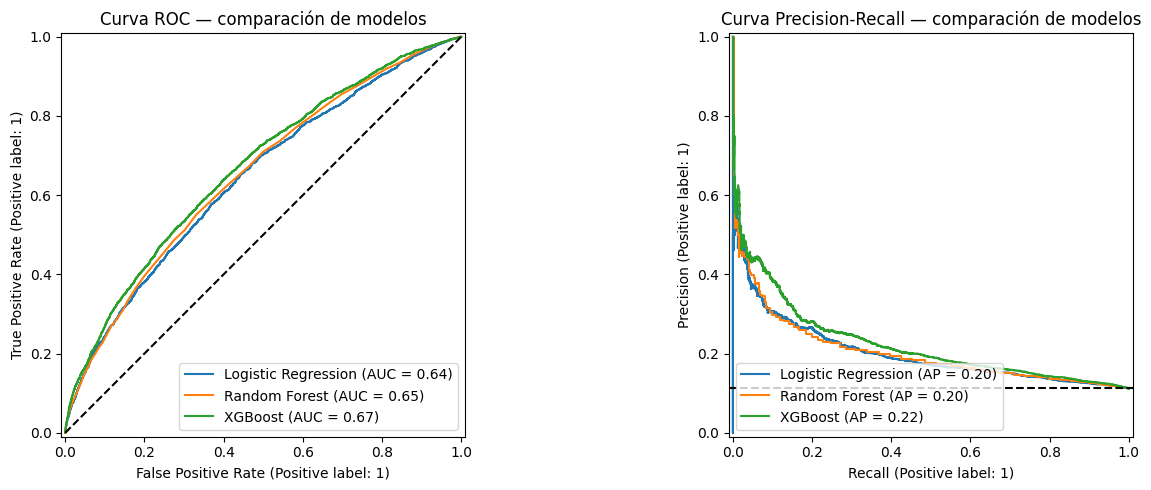

In [32]:
from sklearn.metrics import average_precision_score, PrecisionRecallDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

# PR-AUC para los tres modelos
prauc_lr  = average_precision_score(y_test, pred_balanced)
prauc_rf  = average_precision_score(y_test, pred_rf)
prauc_xgb = average_precision_score(y_test, pred_xgb)

baseline_rate = y_test.mean()

print(f"Baseline aleatorio (proporción positivos): {baseline_rate:.3f}")
print(f"Logistic Regression  PR-AUC: {prauc_lr:.3f}")
print(f"Random Forest        PR-AUC: {prauc_rf:.3f}")
print(f"XGBoost              PR-AUC: {prauc_xgb:.3f}")

# curvas ROC y PR comparativas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for pred, name in [(pred_balanced, "Logistic Regression"),
                   (pred_rf, "Random Forest"),
                   (pred_xgb, "XGBoost")]:
    RocCurveDisplay.from_predictions(y_test, pred, name=name, ax=axes[0])

axes[0].set_title("Curva ROC — comparación de modelos")
axes[0].plot([0,1],[0,1], "k--", label="Random")

for pred, name in [(pred_balanced, "Logistic Regression"),
                   (pred_rf, "Random Forest"),
                   (pred_xgb, "XGBoost")]:
    PrecisionRecallDisplay.from_predictions(y_test, pred, name=name, ax=axes[1])

axes[1].axhline(y=baseline_rate, color="k", linestyle="--", label=f"Random ({baseline_rate:.3f})")
axes[1].set_title("Curva Precision-Recall — comparación de modelos")

plt.tight_layout()
plt.savefig("../reports/figures/roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

Umbral óptimo (F2):  0.418
F2-score en umbral:  0.420
Precision en umbral: 0.154
Recall en umbral:    0.738


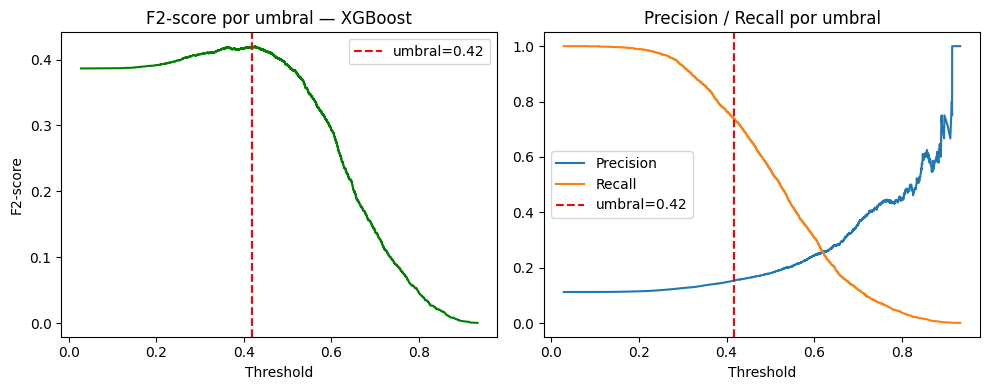

In [33]:
from sklearn.metrics import precision_recall_curve, fbeta_score
import numpy as np

# curva precision-recall sobre XGBoost
precisions, recalls, thresholds = precision_recall_curve(y_test, pred_xgb)

# F2-score para cada umbral (recall pesa el doble que precision)
f2_scores = (1 + 2**2) * (precisions[:-1] * recalls[:-1]) / \
            (2**2 * precisions[:-1] + recalls[:-1] + 1e-8)

# umbral óptimo
best_idx = np.argmax(f2_scores)
best_threshold = thresholds[best_idx]
best_f2 = f2_scores[best_idx]

print(f"Umbral óptimo (F2):  {best_threshold:.3f}")
print(f"F2-score en umbral:  {best_f2:.3f}")
print(f"Precision en umbral: {precisions[best_idx]:.3f}")
print(f"Recall en umbral:    {recalls[best_idx]:.3f}")

# visualización
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(thresholds, f2_scores, color="green")
plt.axvline(best_threshold, color="red", linestyle="--", label=f"umbral={best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("F2-score")
plt.title("F2-score por umbral — XGBoost")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.axvline(best_threshold, color="red", linestyle="--", label=f"umbral={best_threshold:.2f}")
plt.xlabel("Threshold")
plt.title("Precision / Recall por umbral")
plt.legend()

plt.tight_layout()
plt.savefig("../reports/figures/threshold_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

## Threshold Tuning — XGBoost

### Justificación metodológica
El umbral por defecto de 0.5 no es óptimo en problemas con desbalance severo y costos asimétricos.
En readmisión hospitalaria, el costo de un **falso negativo** (no detectar a alguien que va a ser
readmitido) es clínicamente mayor que el de un **falso positivo** (generar una alerta innecesaria).

Por eso se optimiza **F2-score**, que pondera el recall el doble que la precision.

### Resultado

| Métrica | Valor |
|---|---|
| Umbral óptimo (F2) | **0.42** |
| F2-score | 0.420 |
| Recall (clase positiva) | **0.738** |
| Precision (clase positiva) | 0.154 |

### Interpretación
- El modelo detecta el **73.8% de las readmisiones reales** en el set de test
- De cada 10 alarmas generadas, ~1.5 corresponden a readmisiones reales
- Este trade-off es aceptable dado el contexto: priorizar detección sobre precisión

### Limitación explícita
Una precision de 0.154 implica una tasa alta de falsos positivos.
En un contexto operacional real, esto requeriría evaluación del costo de las intervenciones
asociadas a cada alerta. Este proyecto es analítico — no se propone implementación clínica.

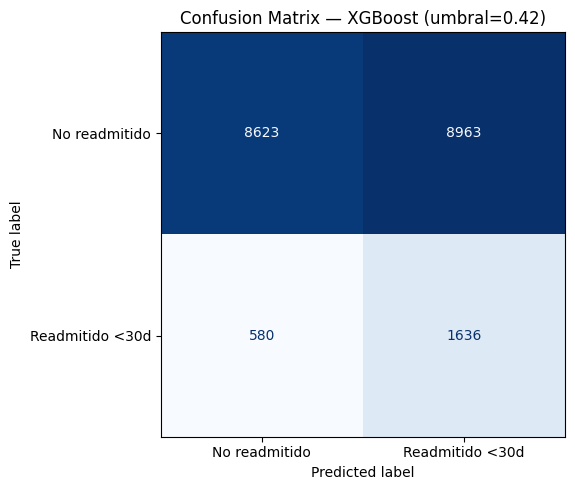

TN: 8623 | FP: 8963
FN: 580 | TP: 1636
Recall:    0.738
Precision: 0.154
Specificity (TN rate): 0.490


In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# predicciones con umbral ajustado
y_pred_tuned = (pred_xgb >= best_threshold).astype(int)

# confusion matrix
cm = confusion_matrix(y_test, y_pred_tuned)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No readmitido", "Readmitido <30d"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")

ax.set_title(f"Confusion Matrix — XGBoost (umbral={best_threshold:.2f})")
plt.tight_layout()
plt.savefig("../reports/figures/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# métricas derivadas
tn, fp, fn, tp = cm.ravel()
print(f"TN: {tn} | FP: {fp}")
print(f"FN: {fn} | TP: {tp}")
print(f"Recall:    {tp / (tp + fn):.3f}")
print(f"Precision: {tp / (tp + fp):.3f}")
print(f"Specificity (TN rate): {tn / (tn + fp):.3f}")

## Confusion Matrix — XGBoost (umbral=0.42)

|  | Predicho: No readmitido | Predicho: Readmitido <30d |
|---|---|---|
| **Real: No readmitido** | 8.623 (TN) | 8.963 (FP) |
| **Real: Readmitido <30d** | 580 (FN) | 1.636 (TP) |

### Métricas derivadas

| Métrica | Valor | Interpretación |
|---|---|---|
| Recall | 0.738 | El modelo detecta el 73.8% de las readmisiones reales |
| Precision | 0.154 | 1 de cada ~6.5 alarmas es una readmisión real |
| Specificity | 0.490 | El 49% de los no-readmitidos son correctamente descartados |

### Interpretación del trade-off
El modelo sacrifica especificidad deliberadamente para maximizar detección.
Con umbral=0.42 y F2-score como criterio:

- **580 readmisiones no detectadas (FN)** → el error clínicamente más costoso, minimizado
- **8.963 alertas innecesarias (FP)** → costo operacional aceptable dado el contexto

Este trade-off es una decisión explícita, no una limitación del modelo.
En un sistema de salud real, el costo relativo de FN vs FP dependería
de la intervención asociada a cada alerta y requeriría validación prospectiva.

In [35]:
import shap

# extraer componentes del pipeline
preprocessor = model_xgb.named_steps["preprocess"]
clf = model_xgb.named_steps["clf"]

# transformar X_test
X_test_transformed = preprocessor.transform(X_test)

# nombres de features post-preprocesamiento
cat_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols).tolist()
all_feature_names = cat_feature_names + num_cols

# SHAP explainer
explainer = shap.TreeExplainer(clf)
shap_values = explainer(X_test_transformed)
shap_values.feature_names = all_feature_names

print("SHAP values calculados:", shap_values.values.shape)

SHAP values calculados: (19802, 2417)


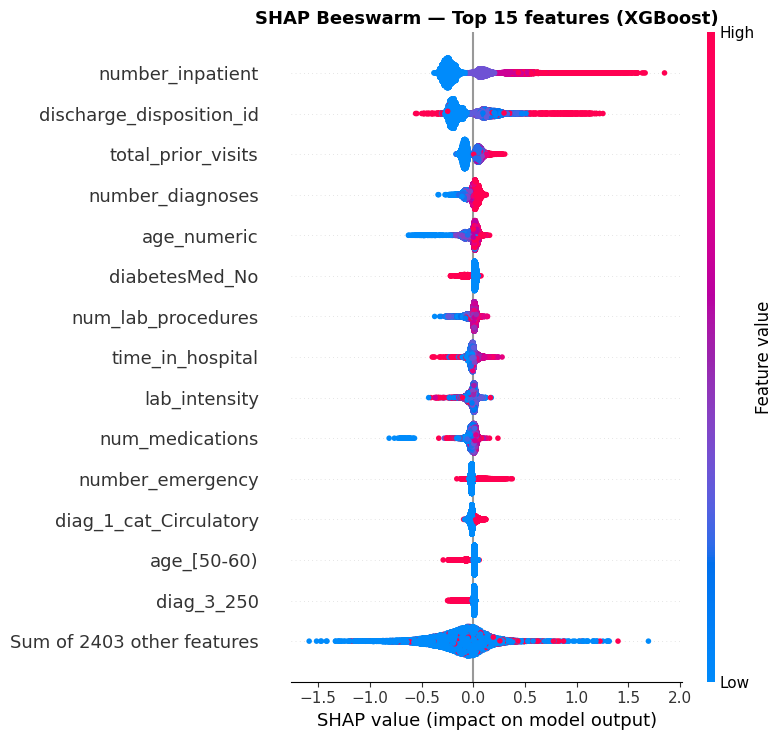

In [36]:
# SHAP beeswarm — importancia global top 15
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("SHAP Beeswarm — Top 15 features (XGBoost)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

## SHAP — Interpretabilidad Global (XGBoost)

### Beeswarm plot — Top 15 features

Las features se ordenan por importancia media absoluta (impacto promedio en el output del modelo).
Rosa = valor alto de la feature | Azul = valor bajo.

### Hallazgos principales

**Utilización hospitalaria previa — señal más fuerte**
- `number_inpatient`: top feature por amplio margen. Valores altos empujan
  fuertemente hacia readmisión. Historia de internaciones previas es el predictor
  más robusto del modelo.
- `total_prior_visits`: suma de visitas previas (outpatient + emergency + inpatient)
  confirma la señal. Feature construido en el feature engineering.
- `number_emergency`: visitas previas a emergencias también aportan señal positiva.

**Características de la internación actual**
- `discharge_disposition_id`: el destino al alta tiene impacto alto y bidireccional —
  distintas categorías de destino empujan en direcciones opuestas.
- `number_diagnoses`: más diagnósticos activos asociados a mayor riesgo.
- `num_lab_procedures` y `time_in_hospital`: carga diagnóstica y duración
  de internación aportan señal moderada.
- `lab_intensity`: ratio de procedimientos por día — feature construido,
  aparece en top 15.

**Variables demográficas y clínicas**
- `age_numeric`: edad tiene impacto moderado y bidireccional.
- `age_[50-60)`: rango etario específico con señal negativa (menor riesgo relativo).
- `diag_1_cat_Circulatory`: diagnóstico primario circulatorio asociado a mayor riesgo.
- `diag_3_250`: código ICD-9 250 (diabetes) como diagnóstico terciario — señal presente.

**Medicación**
- `diabetesMed_No`: no recibir medicación para diabetes aparece asociado a
  menor riesgo de readmisión. Resultado contraintuitivo — posible explicación:
  pacientes sin medicación pueden ser casos menos severos o de menor complejidad.
- `insulina` **no aparece en top 15** — su señal individual es menor de lo esperado
  por plausibilidad clínica. Consistente con el análisis exploratorio donde las
  diferencias por categoría de insulina eran modestas (10–14%).

### Advertencia metodológica
SHAP muestra asociación estadística, no causalidad.
Las features con mayor impacto no son necesariamente intervenibles.
`number_inpatient` es el predictor más fuerte, pero una internación previa
no es una variable sobre la que se pueda actuar al momento del alta. 

In [37]:
# seleccionar 3 perfiles representativos del test set
# perfil 1 — alto riesgo (score alto, readmitido real)
# perfil 2 — bajo riesgo (score bajo, no readmitido real)
# perfil 3 — falso negativo (score bajo, pero readmitido real)

scores = pred_xgb
real = y_test.values

# perfil 1 — alto riesgo, readmitido real (TP)
tp_mask = (scores >= best_threshold) & (real == 1)
idx_tp = np.where(tp_mask)[0][0]

# perfil 2 — bajo riesgo, no readmitido (TN)
tn_mask = (scores < best_threshold) & (real == 0)
idx_tn = np.where(tn_mask)[0][0]

# perfil 3 — falso negativo (FN) — readmitido pero no detectado
fn_mask = (scores < best_threshold) & (real == 1)
idx_fn = np.where(fn_mask)[0][0]

print(f"Perfil 1 (TP) — score: {scores[idx_tp]:.3f} | real: {real[idx_tp]}")
print(f"Perfil 2 (TN) — score: {scores[idx_tn]:.3f} | real: {real[idx_tn]}")
print(f"Perfil 3 (FN) — score: {scores[idx_fn]:.3f} | real: {real[idx_fn]}")

Perfil 1 (TP) — score: 0.533 | real: 1
Perfil 2 (TN) — score: 0.399 | real: 0
Perfil 3 (FN) — score: 0.410 | real: 1


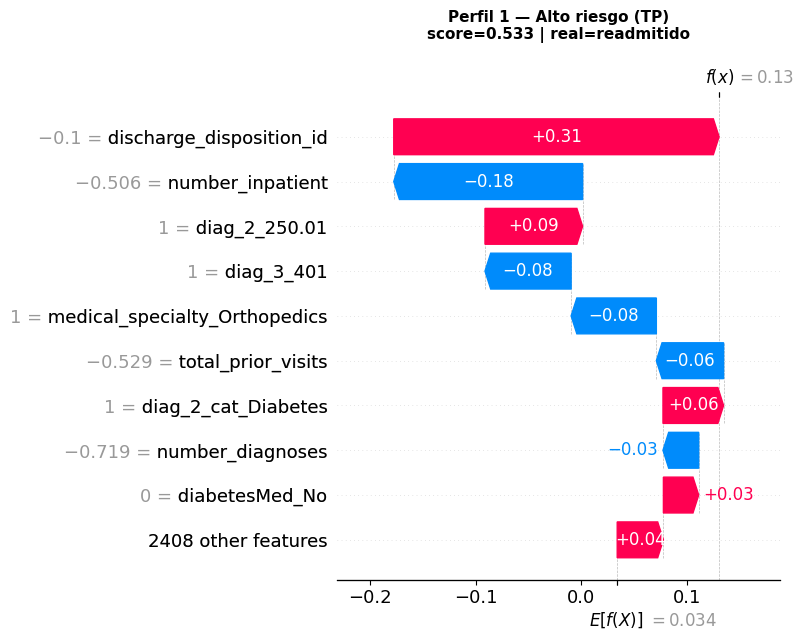

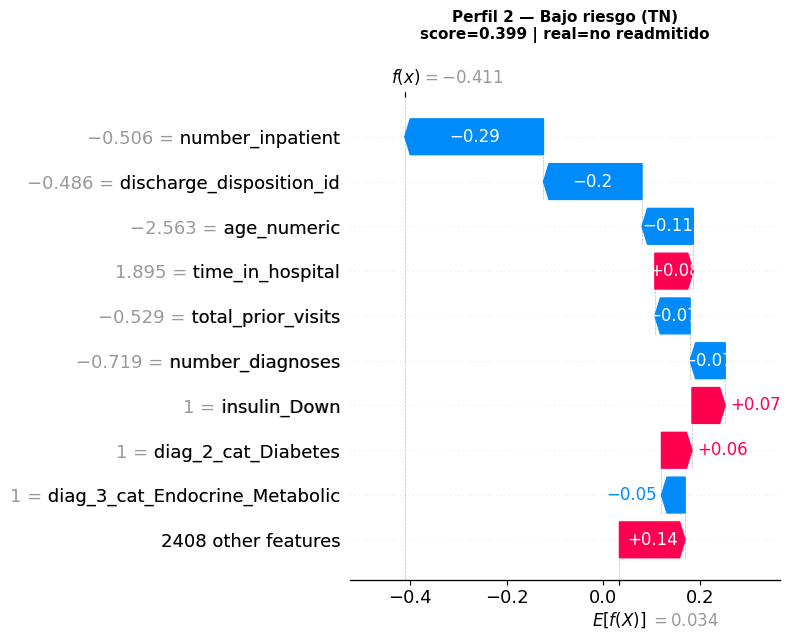

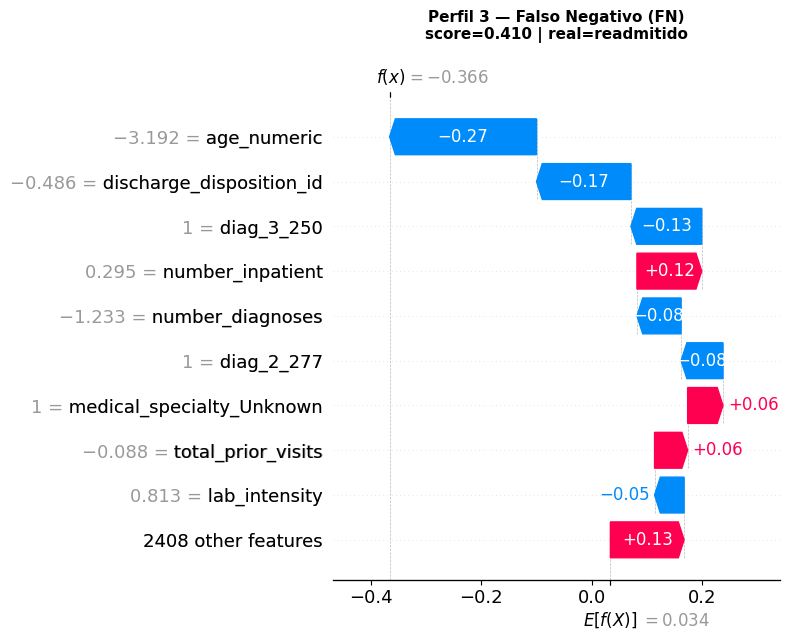

In [39]:
perfiles = [
    (idx_tp, "Perfil 1 — Alto riesgo (TP)", f"score={scores[idx_tp]:.3f} | real=readmitido"),
    (idx_tn, "Perfil 2 — Bajo riesgo (TN)", f"score={scores[idx_tn]:.3f} | real=no readmitido"),
    (idx_fn, "Perfil 3 — Falso Negativo (FN)", f"score={scores[idx_fn]:.3f} | real=readmitido"),
]

for idx, titulo, subtitulo in perfiles:
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_values[idx], max_display=10, show=False)
    plt.title(f"{titulo}\n{subtitulo}", fontsize=11, fontweight="bold", pad=20)
    plt.tight_layout()
    nombre = titulo.split("—")[0].strip().replace(" ", "_").lower()
    plt.savefig(f"../reports/figures/shap_waterfall_{nombre}.png", dpi=150, bbox_inches="tight")
    plt.show()

## SHAP — Interpretabilidad Local (Waterfall plots)

### Perfil 1 — Alto riesgo (TP) | score=0.533 | real=readmitido
- `discharge_disposition_id` es el driver principal (+0.31) — el destino al alta
  empuja fuertemente hacia readmisión en este caso
- `number_inpatient` bajo (-0.18) actúa como contrapeso — poca historia previa
- `diag_2_250.01` (diabetes como diagnóstico secundario) suma riesgo (+0.09)
- El modelo lo detecta correctamente a pesar de tener pocas internaciones previas

### Perfil 2 — Bajo riesgo (TN) | score=0.399 | real=no readmitido
- `number_inpatient` y `discharge_disposition_id` empujan fuertemente hacia
  no readmisión (-0.29 y -0.20)
- `age_numeric` bajo (-0.11) — paciente joven, menor riesgo
- `insulin_Down` aparece con señal positiva (+0.07) — consistente con el
  análisis exploratorio donde reducción de insulina asociaba mayor riesgo
- El modelo lo clasifica correctamente: señales protectoras dominan

### Perfil 3 — Falso Negativo (FN) | score=0.410 | real=readmitido
- El modelo no lo detecta porque el perfil parece protector:
  edad baja (-0.27), destino al alta favorable (-0.17)
- `number_inpatient` bajo (+0.12) — poca historia hospitalaria previa
- `diag_3_250` empuja negativamente (-0.13) — patrón atípico
- Este caso ilustra el límite del modelo: pacientes jóvenes con poca
  historia previa pero que igual se readmiten son difíciles de capturar

### Conexión con análisis de medicación
`insulin_Down` aparece en el Perfil 2 con señal positiva de riesgo (+0.07),
consistente con el hallazgo exploratorio: reducción de dosis de insulina
al alta asociada a mayor tasa de readmisión (14.2% vs 10.2% en No).

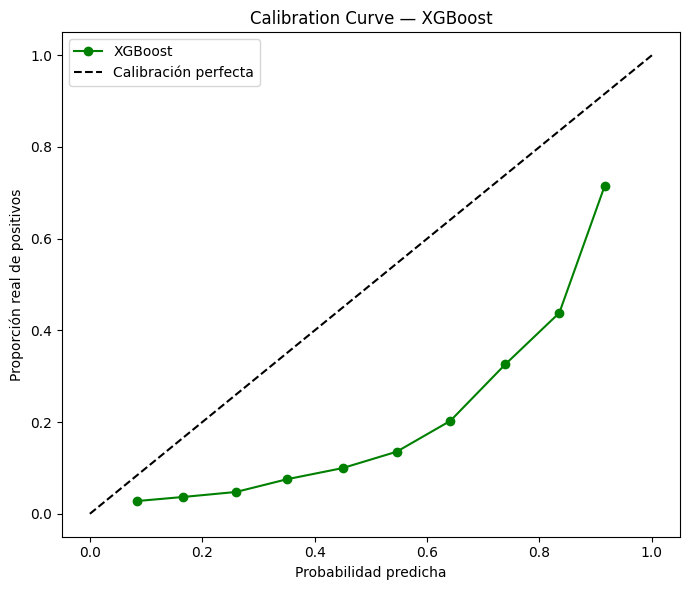

Brier Score: 0.2098  (0=perfecto, 1=peor)


In [40]:
from sklearn.calibration import calibration_curve

# calibration curve para XGBoost
prob_true, prob_pred = calibration_curve(y_test, pred_xgb, n_bins=10)

plt.figure(figsize=(7, 6))
plt.plot(prob_pred, prob_true, marker="o", label="XGBoost", color="green")
plt.plot([0, 1], [0, 1], "k--", label="Calibración perfecta")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Proporción real de positivos")
plt.title("Calibration Curve — XGBoost")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/calibration_curve.png", dpi=150, bbox_inches="tight")
plt.show()

# métricas de calibración
from sklearn.metrics import brier_score_loss
brier = brier_score_loss(y_test, pred_xgb)
print(f"Brier Score: {brier:.4f}  (0=perfecto, 1=peor)")

## Calibration Curve — XGBoost

### Resultado
- **Brier Score: 0.2098** — moderado, esperable con desbalance severo
- El modelo está **subcalibrado**: las probabilidades predichas son
  sistemáticamente más altas que la proporción real de positivos
- Ejemplo: cuando el modelo predice 0.6, solo ~20% de esos casos
  son readmisiones reales

### Causa
Esperado con `scale_pos_weight=7.74` — el modelo penaliza fuertemente
los falsos negativos, empujando los scores hacia arriba para maximizar
detección. Esto infla las probabilidades absolutas.

### Implicación
Las probabilidades del modelo **no deben interpretarse como probabilidades
clínicas reales**. El modelo es útil para **rankear pacientes por riesgo
relativo**, no para estimar probabilidad absoluta de readmisión.

Si se requiriera calibración, se aplicaría Platt Scaling o Isotonic
Regression post-hoc. Para este proyecto analítico, el ranking es suficiente.

In [41]:
import pickle
import os

os.makedirs("../models", exist_ok=True)

# guardar modelo XGBoost
with open("../models/xgb_readmission.pkl", "wb") as f:
    pickle.dump(model_xgb, f)

# guardar umbral elegido
with open("../models/threshold.txt", "w") as f:
    f.write(f"threshold={best_threshold:.4f}\n")
    f.write(f"criterio=F2-score (recall pesa doble que precision)\n")
    f.write(f"recall={recalls[best_idx]:.4f}\n")
    f.write(f"precision={precisions[best_idx]:.4f}\n")
    f.write(f"f2={best_f2:.4f}\n")

print("Modelo guardado: ../models/xgb_readmission.pkl")
print("Umbral guardado: ../models/threshold.txt")

Modelo guardado: ../models/xgb_readmission.pkl
Umbral guardado: ../models/threshold.txt
